In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

## 1 — Load & Parse Data: Ecolane reservation and trip dataset


In [2]:
from pathlib import Path
from openpyxl import load_workbook


EXCEL_PATH = Path(
    "/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/"
    "Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx"
)
ECOLANE_SHEET = "SMART Trip Data"

# Read the Ecolane fields needed by the rest of this notebook, then create the
# address/coordinate helper columns used by the existing analysis cells.
ecolane_source_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID',
    'Earliest Pick-up', 'Latest Drop-off Time',
    'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    'Pick-up Latitude', 'Pick-up Longitude',
    'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Drop-off Latitude', 'Drop-off Longitude',
    'Purpose', 'Cancel Type',
]


def read_excel_columns(path, sheet_name, columns):
    workbook = load_workbook(path, read_only=True, data_only=True)
    worksheet = workbook[sheet_name]
    headers = list(next(worksheet.iter_rows(min_row=1, max_row=1, values_only=True)))
    missing = [column for column in columns if column not in headers]
    if missing:
        workbook.close()
        raise KeyError(f"Missing expected Ecolane columns: {missing}")
    column_positions = [headers.index(column) for column in columns]
    records = [
        [row[position] for position in column_positions]
        for row in worksheet.iter_rows(min_row=2, values_only=True)
    ]
    workbook.close()
    return pd.DataFrame.from_records(records, columns=columns)


df_raw = read_excel_columns(EXCEL_PATH, ECOLANE_SHEET, ecolane_source_cols)


def format_address_part(value):
    if pd.isna(value):
        return ''
    if isinstance(value, float) and value.is_integer():
        return str(int(value))
    return str(value).strip()


def build_address(df, prefix):
    number = df[f'{prefix} Street Number'].map(format_address_part)
    street = df[f'{prefix} Street'].map(format_address_part)
    zipcode = df[f'{prefix} Zipcode'].map(format_address_part)
    street_address = (number + ' ' + street).str.strip()
    return np.where(zipcode.ne(''), street_address + ', ' + zipcode, street_address)


df_raw['pickup_address'] = build_address(df_raw, 'Pick-up')
df_raw['dropoff_address'] = build_address(df_raw, 'Drop-off')
df_raw['pickup_lat'] = pd.to_numeric(df_raw['Pick-up Latitude'], errors='coerce')
df_raw['pickup_lon'] = pd.to_numeric(df_raw['Pick-up Longitude'], errors='coerce')
df_raw['dropoff_lat'] = pd.to_numeric(df_raw['Drop-off Latitude'], errors='coerce')
df_raw['dropoff_lon'] = pd.to_numeric(df_raw['Drop-off Longitude'], errors='coerce')

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(['comp', 'completed']).sum()
cancelled_trips = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
noshow_trips = status_clean.isin(['noshow', 'no show', 'no-show']).sum()

print(f"Input workbook: {EXCEL_PATH.name}")
print(f"Input sheet: {ECOLANE_SHEET}")
print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
print(f"Columns:  {list(df_raw.columns)}")
df_raw.head(3)


Input workbook: Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx
Input sheet: SMART Trip Data
Total trips: 121,281
Completed trips: 63,841
Cancelled trips: 54,121
No-show trips: 3,319
Unique customers: 1,052
Purpose types (10): ['Dialysis', 'Education', 'Employment', 'Medical', 'Nutrition', 'Personal', 'Recreation', 'Shopping', 'Trolley', 'Workshop']
Trip date range: 2022-07-01 to 2023-06-30
Columns:  ['Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID', 'Earliest Pick-up', 'Latest Drop-off Time', 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode', 'Pick-up Latitude', 'Pick-up Longitude', 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode', 'Drop-off Latitude', 'Drop-off Longitude', 'Purpose', 'Cancel Type', 'pickup_address', 'dropoff_address', 'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon']


,Customer Number,Trip ID,Trip Date,Trip Status,Run ID,Earliest Pick-up,Latest Drop-off Time,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,...,Drop-off Latitude,Drop-off Longitude,Purpose,Cancel Type,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
0,23083,286854,2022-07-01,cancel,None,05:07:00,05:49:00,Forest Way,407,35094.0,...,33.531577,-86.715948,Dialysis,Renegotiation,"407 Forest Way, 35094","7780 Ludington Ln, 35210",33.543593,-86.572576,33.531577,-86.715948
1,14909,286738,2022-07-01,comp,E&I-102,05:30:00,06:48:00,Glynn Dr,308,35215.0,...,33.475050,-86.823489,Employment,None,"308 Glynn Dr, 35215","529 Beacon Pkwy W, 35209",33.603306,-86.711765,33.475050,-86.823489
2,6712,286886,2022-07-01,comp,Finch,06:00:00,07:03:00,Chattanooga St,1520,35094.0,...,33.531577,-86.715948,Dialysis,None,"1520 Chattanooga St, 35094","7780 Ludington Ln, 35210",33.546257,-86.558513,33.531577,-86.715948


# Here, we discuss the completion rate for each purpose, and we also summarize the cancellation types. 

In [3]:
purpose_completion_rate = (
    df_raw.assign(status_clean=status_clean)
    .dropna(subset=['Purpose'])
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
)

purpose_completion_rate['completed_rate'] = (
    purpose_completion_rate['completed_trips'] / purpose_completion_rate['total_trips']
)
purpose_completion_rate = purpose_completion_rate.sort_values('completed_rate', ascending=False)

display(purpose_completion_rate.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

cancel_statuses = ['cancel', 'canceled', 'cancelled']
cancelled_mask = status_clean.isin(cancel_statuses)
df_cancelled = df_raw.loc[cancelled_mask].copy()
df_cancelled['cancel_type_clean'] = (
    df_cancelled['Cancel Type']
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

total_cancellations = int(cancelled_mask.sum())
cancel_type_summary = (
    df_cancelled
    .groupby('cancel_type_clean')
    .agg(num_cancellations=('Trip ID', 'count'))
    .sort_values('num_cancellations', ascending=False)
)
cancel_type_summary['share_of_cancellations'] = (
    cancel_type_summary['num_cancellations'] / total_cancellations
)

print(f"Total cancellations: {total_cancellations:,}")
print(f"Cancellation types: {cancel_type_summary.shape[0]:,}")
display(cancel_type_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'share_of_cancellations': '{:.2%}',
}))


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
Trolley,12,12,0,0,100.00%
Dialysis,"13,186","7,851","5,078",257,59.54%
Workshop,"5,511","3,204","2,245",62,58.14%
Education,"1,526",878,634,14,57.54%
Employment,"13,619","7,818","5,582",219,57.41%
Nutrition,"64,285","36,847","25,229","2,209",57.32%
Recreation,"1,001",409,554,38,40.86%
Shopping,"2,192",668,"1,492",32,30.47%
Medical,"17,015","5,169","11,404",442,30.38%


Total cancellations: 54,121
Cancellation types: 16


,num_cancellations,share_of_cancellations
cancel_type_clean,,
Advanced Cancel,"16,075",29.70%
Trip correction,"16,017",29.59%
Modified,"6,805",12.57%
Renegotiation,"6,650",12.29%
Site closure,"4,310",7.96%
Denial,"2,081",3.85%
Late Cancel,"1,017",1.88%
User Error Cancel,754,1.39%
Policy Cancel,181,0.33%


# 2. Prepare clean datasets


In [4]:
keep_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID',
    'Earliest Pick-up', 'Latest Drop-off Time',
    'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Purpose', 'pickup_address', 'dropoff_address',
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
]

# Clean trip table for flexibility indices: required fields present, no Trip Status filter.
df_index_clean = df_raw[keep_cols].dropna(subset=keep_cols).copy()

# Completed-only table retained for earlier completed-trip analyses, regularity, and actual-pickup matching.
df_clean = df_index_clean[
    df_index_clean['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])
].copy()

print(f"Rows after required-column NaN filtering, all statuses: {len(df_index_clean):,}")
print(f"Completed rows after required-column NaN filtering: {len(df_clean):,}")

df_index_clean.head(3)


Rows after required-column NaN filtering, all statuses: 102,522
Completed rows after required-column NaN filtering: 63,576


,Customer Number,Trip ID,Trip Date,Trip Status,Run ID,Earliest Pick-up,Latest Drop-off Time,Pick-up Street,Pick-up Street Number,Pick-up Zipcode,Drop-off Street,Drop-off Street Number,Drop-off Zipcode,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
1,14909,286738,2022-07-01,comp,E&I-102,05:30:00,06:48:00,Glynn Dr,308,35215.0,Beacon Pkwy W,529,35209.0,Employment,"308 Glynn Dr, 35215","529 Beacon Pkwy W, 35209",33.603306,-86.711765,33.475050,-86.823489
2,6712,286886,2022-07-01,comp,Finch,06:00:00,07:03:00,Chattanooga St,1520,35094.0,Ludington Ln,7780,35210.0,Dialysis,"1520 Chattanooga St, 35094","7780 Ludington Ln, 35210",33.546257,-86.558513,33.531577,-86.715948
3,5801,286851,2022-07-01,comp,Finch,06:00:00,07:03:00,Chattanooga St,1520,35094.0,Ludington Ln,7780,35210.0,Dialysis,"1520 Chattanooga St, 35094","7780 Ludington Ln, 35210",33.546257,-86.558513,33.531577,-86.715948


# Time of Day distribution from Earliest pickup time for different purpose

Completed-trip demand by earliest pickup hour and purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,,,,
Nutrition,0,0,0,0,0,0,136,"6,695","10,894",311,271,506,"8,602","9,372",59,1,0,0,0,0,0,0,0,0
Dialysis,0,0,0,0,0,73,260,2,440,"2,132","1,168",255,570,97,"1,063","1,716",72,3,0,0,0,0,0,0
Employment,0,0,0,0,0,223,869,560,675,956,128,518,134,413,"1,176","1,585",580,1,0,0,0,0,0,0
Medical,0,0,0,0,0,0,15,202,606,"1,077",634,596,693,602,432,293,16,0,0,0,0,0,0,0
Workshop,0,0,0,0,0,0,336,965,188,101,0,0,5,3,"1,412",193,1,0,0,0,0,0,0,0
Education,0,0,0,0,0,0,36,266,43,80,2,30,86,3,270,61,1,0,0,0,0,0,0,0
Personal,0,0,0,0,0,0,0,3,35,158,131,77,129,90,84,28,1,0,0,0,0,0,0,0
Shopping,0,0,0,0,0,0,0,0,8,122,170,60,71,132,81,21,1,0,0,0,0,0,0,0
Recreation,0,0,0,0,0,0,2,62,46,58,31,18,58,62,64,3,5,0,0,0,0,0,0,0


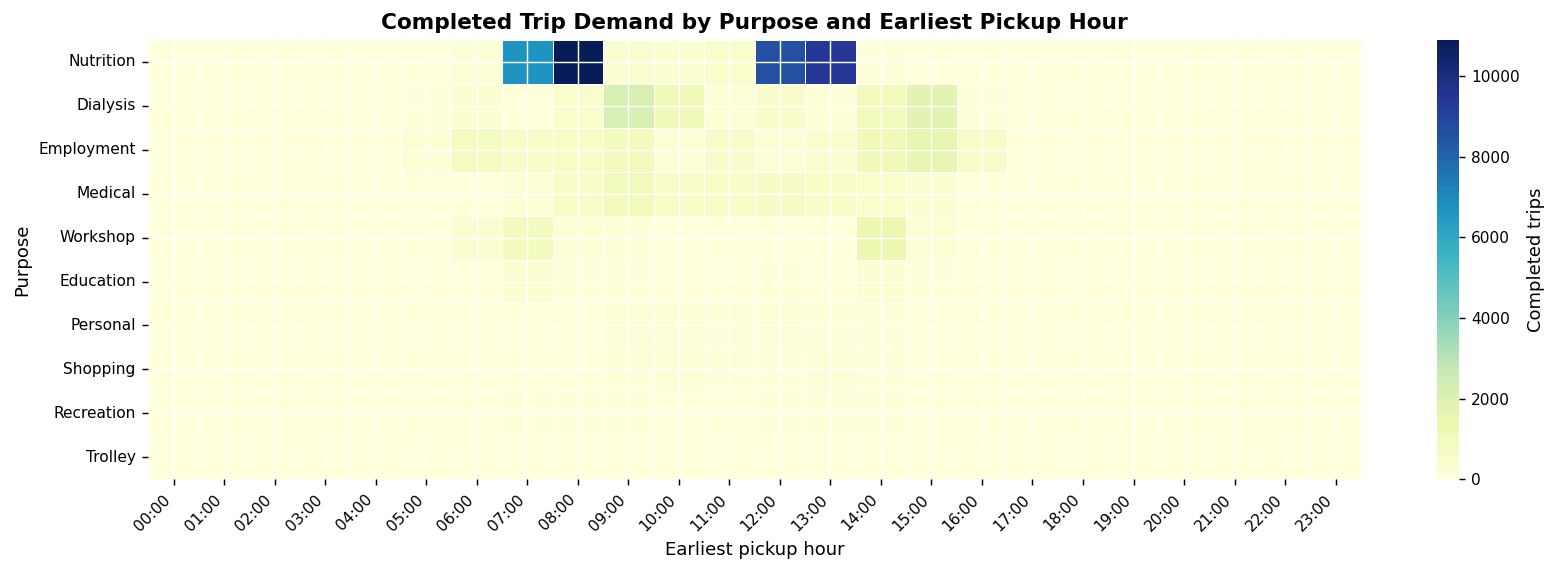

In [5]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

df_time_demand = df_clean.copy()
df_time_demand['pickup_hour'] = df_time_demand['Earliest Pick-up'].apply(hour_from_time)
df_time_demand = df_time_demand.dropna(subset=['Purpose', 'pickup_hour']).copy()
df_time_demand['pickup_hour'] = df_time_demand['pickup_hour'].astype(int)

purpose_hourly_demand = (
    df_time_demand
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

purpose_hourly_demand = purpose_hourly_demand.loc[
    purpose_hourly_demand.sum(axis=1).sort_values(ascending=False).index
]

print('Completed-trip demand by earliest pickup hour and purpose:')
display(purpose_hourly_demand.style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(13, max(3.5, 0.45 * len(purpose_hourly_demand))))
sns.heatmap(
    purpose_hourly_demand,
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Completed trips'},
    ax=ax,
)
ax.set_title('Completed Trip Demand by Purpose and Earliest Pickup Hour')
ax.set_xlabel('Earliest pickup hour')
ax.set_ylabel('Purpose')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout()


### Rider Regularity Index

This cell measures how routine each rider's completed-trip behavior is. For each customer, it summarizes trip frequency, unique pickup/drop-off/OD patterns, pickup-hour consistency, purpose consistency, and weekday consistency.

The regularity index is computed as:

```text
Rider_regularity_index = 0.4 * OD_regular_i
                       + 0.3 * time_regular_i
                       + 0.2 * purpose_regular_i
                       + 0.1 * weekday_regular_i
```

where each component is a dominant-share measure. A higher value means the rider tends to repeat the same OD pair, time, purpose, and weekday pattern. This score is later subtracted from the flexibility index because highly regular behavior indicates less flexibility.



#### How the regularity components are calculated

For each rider $i$, the notebook groups completed trips by `Customer Number` and calculates each component as a dominant-share score, meaning the share of that rider's trips that fall into their most common category:

- $OD\_regular_i = \max_{od}\; n_{i,od} / N_i$: the fraction of rider $i$'s completed trips using their most frequent origin-destination pair. The OD pair is built from pickup address/coordinates and drop-off address/coordinates.
- $time\_regular_i = \max_{h}\; n_{i,h} / N_i$: the fraction of trips in rider $i$'s most common requested pickup hour, derived from `Earliest Pick-up`.
- $purpose\_regular_i = \max_{p}\; n_{i,p} / N_i$: the fraction of trips with rider $i$'s most common trip `Purpose`.
- $weekday\_regular_i = \max_{d}\; n_{i,d} / N_i$: the fraction of trips on rider $i$'s most common weekday, derived from `Trip Date`.

Here, $N_i$ is rider $i$'s total number of completed trips in `df_clean`. Each score ranges from 0 to 1. Values closer to 1 mean trips are concentrated in one repeated pattern; lower values mean trips are spread across several OD pairs, hours, purposes, or weekdays.



Customers in completed-trip regularity analysis: 806
Mean Rider Regularity Index: 0.588; Median: 0.579


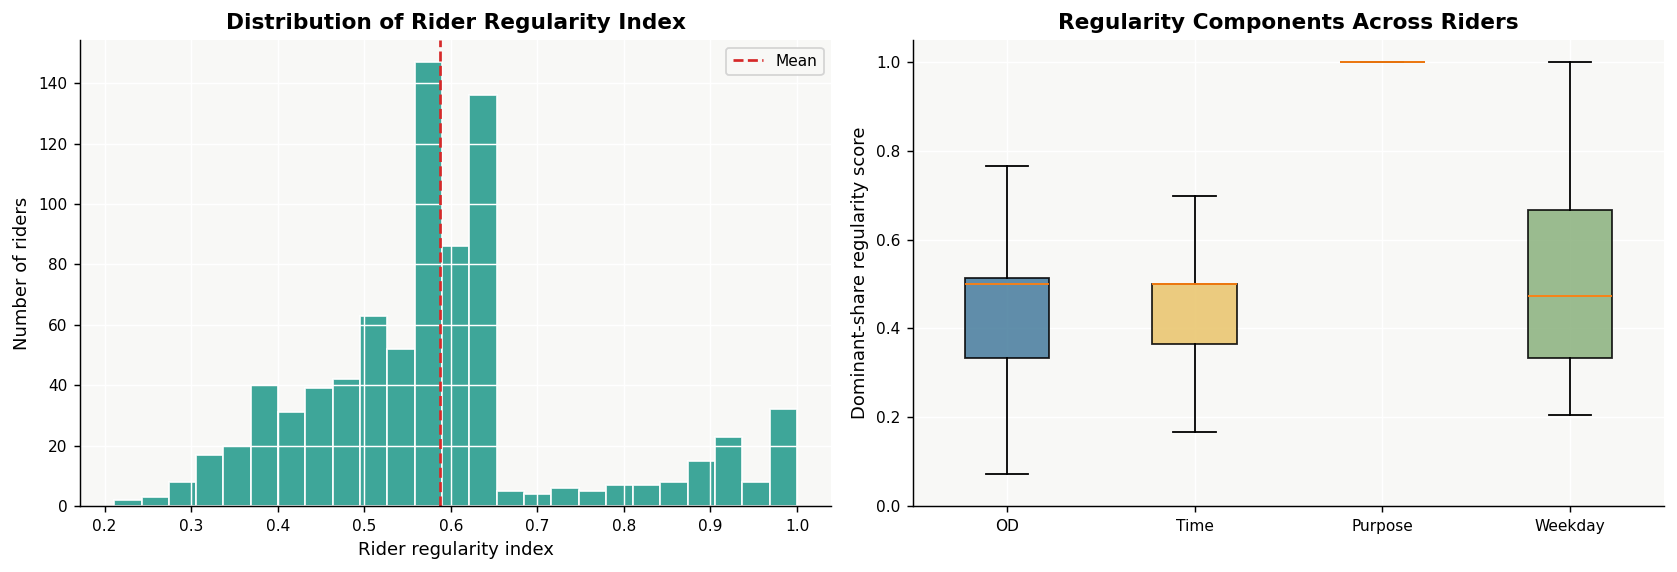

In [6]:
def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()


def dominant_share(s):
    counts = s.dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.iloc[0] / counts.sum()


def pickup_hour_std(s):
    values = s.dropna()
    if values.empty:
        return np.nan
    return values.std(ddof=0)


def entropy_for_series(s):
    return entropy_from_counts(s.dropna().value_counts().to_numpy())

rider_trips = df_clean.copy()
rider_trips['pickup_hour'] = rider_trips['Earliest Pick-up'].apply(hour_from_time)
rider_trips['trip_date_parsed'] = pd.to_datetime(rider_trips['Trip Date'], errors='coerce')
rider_trips['weekday'] = rider_trips['trip_date_parsed'].dt.day_name()
rider_trips['pickup_location_key'] = (
    rider_trips[['pickup_address', 'pickup_lat', 'pickup_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['dropoff_location_key'] = (
    rider_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['od_pair_key'] = (
    rider_trips['pickup_location_key'] + ' -> ' + rider_trips['dropoff_location_key']
)

rider_regularity = (
    rider_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_pickups=('pickup_location_key', 'nunique'),
        num_unique_dropoffs=('dropoff_location_key', 'nunique'),
        num_unique_OD_pairs=('od_pair_key', 'nunique'),
        dominant_OD_share=('od_pair_key', dominant_share),
        pickup_hour_std=('pickup_hour', pickup_hour_std),
        dominant_pickup_hour_share=('pickup_hour', dominant_share),
        time_entropy=('pickup_hour', entropy_for_series),
        num_unique_purposes=('Purpose', 'nunique'),
        dominant_purpose_share=('Purpose', dominant_share),
        num_active_weekdays=('weekday', 'nunique'),
        dominant_weekday_share=('weekday', dominant_share),
        weekday_entropy=('weekday', entropy_for_series),
    )
    .reset_index()
)

rider_regularity['OD_regular_i'] = rider_regularity['dominant_OD_share']
rider_regularity['time_regular_i'] = rider_regularity['dominant_pickup_hour_share']
rider_regularity['purpose_regular_i'] = rider_regularity['dominant_purpose_share']
rider_regularity['weekday_regular_i'] = rider_regularity['dominant_weekday_share']
rider_regularity['Rider_regularity_index'] = (
    0.4 * rider_regularity['OD_regular_i']
    + 0.3 * rider_regularity['time_regular_i']
    + 0.2 * rider_regularity['purpose_regular_i']
    + 0.1 * rider_regularity['weekday_regular_i']
)

rider_regularity = rider_regularity.sort_values(
    ['Rider_regularity_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in completed-trip regularity analysis: {len(rider_regularity):,}")
print(
    f"Mean Rider Regularity Index: {rider_regularity['Rider_regularity_index'].mean():.3f}; "
    f"Median: {rider_regularity['Rider_regularity_index'].median():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(
    rider_regularity['Rider_regularity_index'],
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
    alpha=0.9,
)
axes[0].axvline(
    rider_regularity['Rider_regularity_index'].mean(),
    color='#d62828',
    linestyle='--',
    linewidth=1.5,
    label='Mean',
)
axes[0].set_title('Distribution of Rider Regularity Index')
axes[0].set_xlabel('Rider regularity index')
axes[0].set_ylabel('Number of riders')
axes[0].legend()

component_data = [
    rider_regularity['OD_regular_i'].dropna(),
    rider_regularity['time_regular_i'].dropna(),
    rider_regularity['purpose_regular_i'].dropna(),
    rider_regularity['weekday_regular_i'].dropna(),
]
box = axes[1].boxplot(
    component_data,
    labels=['OD', 'Time', 'Purpose', 'Weekday'],
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(box['boxes'], ['#457b9d', '#e9c46a', '#f4a261', '#8ab17d']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_title('Regularity Components Across Riders')
axes[1].set_ylabel('Dominant-share regularity score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()



### Temporal Flexibility Index

This cell computes a rider-level temporal flexibility score from requested pickup-time diversity only. It uses `df_index_clean`, which drops rows with missing required fields but does not filter to completed trips.

For each rider/customer `i`, the notebook calculates entropy across the rider's requested earliest pickup hours:

```text
earliest_pickup_time_entropy = entropy(earliest_pickup_hour for all clean trips of rider i)
```

The entropy score is min-max normalized across riders and used directly as the temporal flexibility index:

```text
earliest_pickup_time_entropy_norm = minmax(earliest_pickup_time_entropy)
temporal_flexibility_index = earliest_pickup_time_entropy_norm
```

Riders with more diverse requested earliest pickup hours receive higher temporal flexibility scores.


Rows used for temporal flexibility after time parsing: 102,522 / 102,522
Customers with temporal flexibility index: 1,002


,Customer Number,trip_frequency,earliest_pickup_time_entropy,num_unique_earliest_pickup_hours,earliest_pickup_time_entropy_norm,temporal_flexibility_index
127,6613,25,3.01,9,1.000,1.000
768,19680,34,3.01,10,0.998,0.998
718,18317,69,2.99,9,0.993,0.993
245,7290,42,2.98,9,0.990,0.990
736,18888,40,2.98,9,0.990,0.990
818,20858,36,2.97,9,0.984,0.984
175,6940,39,2.95,9,0.979,0.979
216,7179,73,2.93,10,0.971,0.971
899,22691,46,2.92,8,0.970,0.970
66,5890,60,2.91,9,0.967,0.967


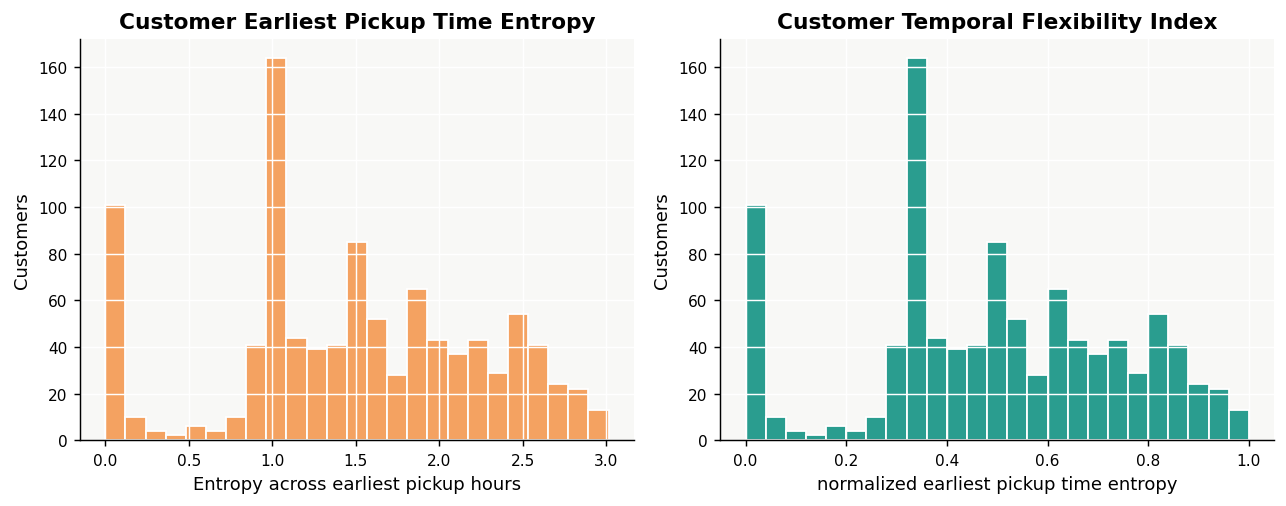

In [7]:
temporal_flexibility_trips = df_index_clean.copy()
temporal_flexibility_trips['earliest_pickup_hour'] = (
    temporal_flexibility_trips['Earliest Pick-up'].apply(hour_from_time)
)
temporal_flexibility_trips = temporal_flexibility_trips.dropna(
    subset=['earliest_pickup_hour']
).copy()


def entropy_bits(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()


def minmax_normalize_series(s):
    s = s.astype(float)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)


customer_temporal_flexibility = (
    temporal_flexibility_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        earliest_pickup_time_entropy=('earliest_pickup_hour', entropy_bits),
        num_unique_earliest_pickup_hours=('earliest_pickup_hour', 'nunique'),
    )
    .reset_index()
)
customer_temporal_flexibility['earliest_pickup_time_entropy_norm'] = minmax_normalize_series(
    customer_temporal_flexibility['earliest_pickup_time_entropy']
)
customer_temporal_flexibility['temporal_flexibility_index'] = (
    customer_temporal_flexibility['earliest_pickup_time_entropy_norm']
)
customer_temporal_flexibility = customer_temporal_flexibility.sort_values(
    ['temporal_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(
    f"Rows used for temporal flexibility after time parsing: "
    f"{len(temporal_flexibility_trips):,} / {len(df_index_clean):,}"
)
print(f"Customers with temporal flexibility index: {customer_temporal_flexibility['temporal_flexibility_index'].notna().sum():,}")

display(customer_temporal_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'earliest_pickup_time_entropy': '{:,.2f}',
    'earliest_pickup_time_entropy_norm': '{:.3f}',
    'num_unique_earliest_pickup_hours': '{:,.0f}',
    'temporal_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    customer_temporal_flexibility['earliest_pickup_time_entropy'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[0].set_title('Customer Earliest Pickup Time Entropy')
axes[0].set_xlabel('Entropy across earliest pickup hours')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_temporal_flexibility['temporal_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[1].set_title('Customer Temporal Flexibility Index')
axes[1].set_xlabel('normalized earliest pickup time entropy')
axes[1].set_ylabel('Customers')

plt.tight_layout()
plt.show()


I found that all routes have the same pickup time with the earliest pickup time.

### Geographical Flexibility Index

This cell measures how spatially flexible each rider's clean-trip destinations are. It now combines two equally weighted components:

```text
GF_i = 0.5 * destination_diversity_score_i
     + 0.5 * purpose_based_destination_density_score_i
```

Each component is calculated as follows:

```text
destination_diversity_score_i = H(destination_zone_i) / log(K_i)

purpose_based_nearby_destination_count_j = sum over k != j of 1(d(j, k) <= r) * 1(p_k = p_j)

purpose_based_destination_density_score_j = log(1 + purpose_based_nearby_destination_count_j)
                                            / log(1 + max_j purpose_based_nearby_destination_count_j)

purpose_based_destination_density_score_i = mean(purpose_based_destination_density_score_j for j in D_i)
```

Here, `H(destination_zone_i)` is entropy over rider `i`'s observed drop-off zones, and `K_i` is the number of unique destination zones for rider `i`. If a rider has only one destination zone, the normalized entropy score is set to `0.0`.

For the purpose-based destination density score, each unique destination `j` is assigned an inferred purpose `p_j` from the dominant observed trip purpose at that destination. For mandatory purposes (`Dialysis`, `Medical`, `Work`, and `School`), the nearby-destination count and density score are set to `0.0`. For non-mandatory purposes, the notebook counts other unique destinations within `PURPOSE_BASED_DESTINATION_RADIUS_M` meters that share the same inferred purpose. The count is log-normalized across destinations and then averaged across each rider's unique clean-trip destinations.

A higher score means the rider has more diverse destinations and/or tends to visit destinations that have more nearby same-purpose destination options.


Customers in geographical flexibility analysis: 1,002
Unique destination locations: 1,804
Mandatory-purpose destinations with density forced to zero: 1,008
Purpose-based destination density radius: 800 meters
Top riders by geographical flexibility index:


,Customer Number,trip_frequency,num_unique_destinations,destination_diversity_score,purpose_based_destination_density_score,avg_purpose_based_nearby_destination_count,num_destination_purposes,dominant_destination_purpose,geographical_flexibility_index
849,21737,16,2,0.989,0.697,5.0,1,Personal,0.843
933,23200,28,3,0.914,0.695,6.8,1,Shopping,0.805
773,19757,2,2,1.000,0.603,5.0,2,Shopping,0.801
708,17933,46,4,0.843,0.723,5.6,2,Shopping,0.783
158,6790,4,2,1.000,0.558,4.0,1,Personal,0.779
18,2293,2,2,1.000,0.558,4.0,1,Shopping,0.779
179,6969,603,2,0.998,0.558,3.0,1,Nutrition,0.778
650,15124,541,2,0.995,0.558,3.0,1,Nutrition,0.777
505,8067,6,3,0.921,0.612,4.0,1,Personal,0.766
792,20152,3,3,1.000,0.519,3.0,1,Personal,0.760


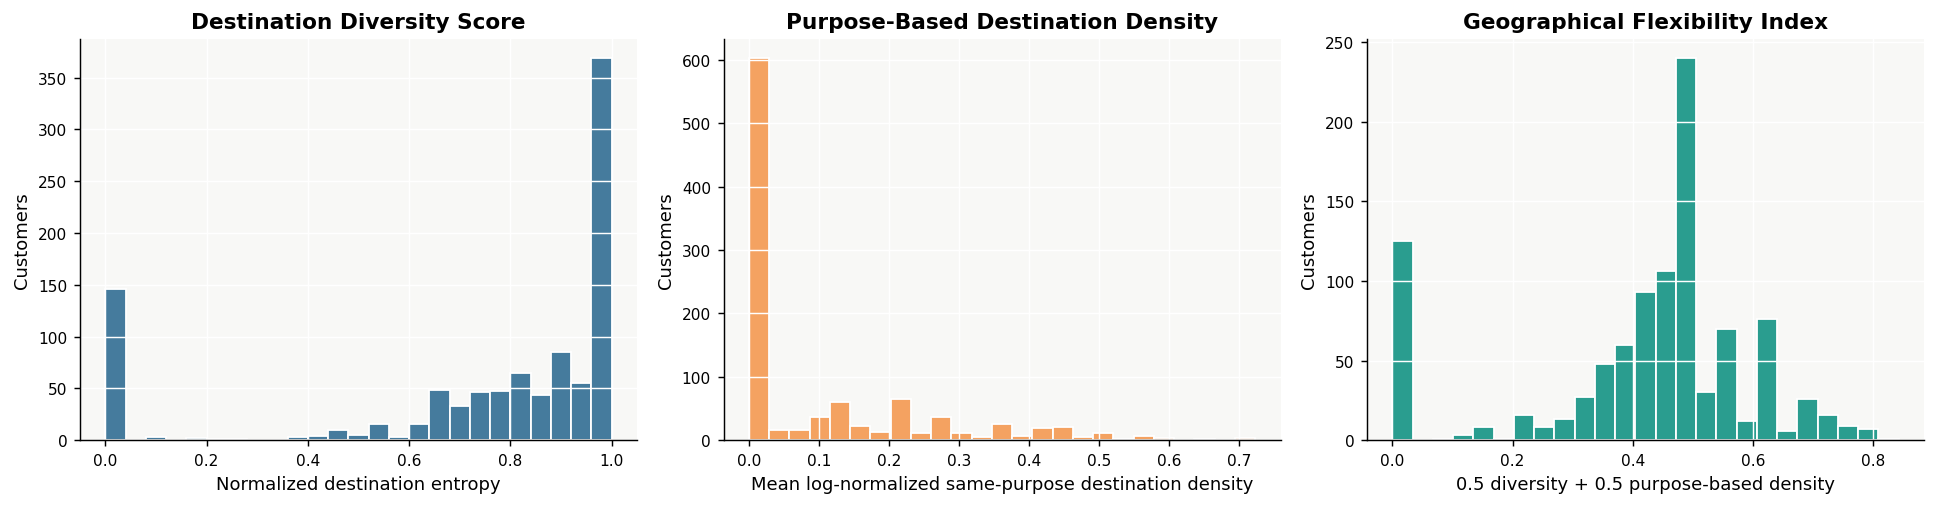

In [8]:
PURPOSE_BASED_DESTINATION_RADIUS_M = 800
MANDATORY_DESTINATION_PURPOSES = {'Dialysis', 'Medical', 'Work', 'School'}


def haversine_matrix_m(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    return 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000


def normalized_entropy(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


def dominant_value(s):
    counts = s.dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.index[0]


geography_trips = df_index_clean.copy()
geography_trips['destination_zone'] = geography_trips['dropoff_address'].astype(str)

unique_destinations = (
    geography_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)

destination_purpose = (
    geography_trips
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'], dropna=False)
    .agg(destination_inferred_purpose=('Purpose', dominant_value))
    .reset_index()
)
unique_destinations = unique_destinations.merge(
    destination_purpose,
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='left',
)

destination_distances_m = haversine_matrix_m(
    unique_destinations['dropoff_lat'],
    unique_destinations['dropoff_lon'],
    unique_destinations['dropoff_lat'],
    unique_destinations['dropoff_lon'],
)
destination_purposes = (
    unique_destinations['destination_inferred_purpose']
    .fillna('Unknown purpose')
    .astype(str)
    .to_numpy()
)
destination_index = np.arange(len(unique_destinations))
purpose_based_destination_counts = np.zeros(len(unique_destinations), dtype=int)

for i, purpose in enumerate(destination_purposes):
    if purpose in MANDATORY_DESTINATION_PURPOSES:
        continue
    same_purpose = destination_purposes == purpose
    nearby_same_purpose = destination_distances_m[i] <= PURPOSE_BASED_DESTINATION_RADIUS_M
    not_self_destination = destination_index != i
    purpose_based_destination_counts[i] = int(
        (same_purpose & nearby_same_purpose & not_self_destination).sum()
    )

unique_destinations['purpose_based_nearby_destination_count'] = purpose_based_destination_counts
max_purpose_based_destination_count = unique_destinations[
    'purpose_based_nearby_destination_count'
].max()
if max_purpose_based_destination_count > 0:
    unique_destinations['purpose_based_destination_density_score'] = (
        np.log1p(unique_destinations['purpose_based_nearby_destination_count'])
        / np.log1p(max_purpose_based_destination_count)
    )
else:
    unique_destinations['purpose_based_destination_density_score'] = 0.0

mandatory_destination_mask = unique_destinations['destination_inferred_purpose'].isin(
    MANDATORY_DESTINATION_PURPOSES
)
unique_destinations.loc[
    mandatory_destination_mask,
    'purpose_based_nearby_destination_count',
] = 0
unique_destinations.loc[
    mandatory_destination_mask,
    'purpose_based_destination_density_score',
] = 0.0

geography_trips = geography_trips.merge(
    unique_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
        'destination_inferred_purpose', 'purpose_based_nearby_destination_count',
        'purpose_based_destination_density_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='left',
)

customer_destination_diversity = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_destinations=('destination_zone', 'nunique'),
        destination_diversity_score=('destination_zone', normalized_entropy),
    )
    .reset_index()
)

rider_destination_scores = (
    geography_trips[[
        'Customer Number', 'dropoff_address', 'dropoff_lat', 'dropoff_lon',
        'destination_inferred_purpose', 'purpose_based_nearby_destination_count',
        'purpose_based_destination_density_score',
    ]]
    .drop_duplicates()
)
customer_destination_density = (
    rider_destination_scores
    .groupby('Customer Number')
    .agg(
        purpose_based_destination_density_score=(
            'purpose_based_destination_density_score', 'mean'
        ),
        avg_purpose_based_nearby_destination_count=(
            'purpose_based_nearby_destination_count', 'mean'
        ),
        num_destination_purposes=('destination_inferred_purpose', 'nunique'),
        dominant_destination_purpose=('destination_inferred_purpose', dominant_value),
    )
    .reset_index()
)

customer_geographical_flexibility = customer_destination_diversity.merge(
    customer_destination_density,
    on='Customer Number',
    how='left',
)

customer_geographical_flexibility['geographical_flexibility_index'] = (
    0.5 * customer_geographical_flexibility['destination_diversity_score']
    + 0.5 * customer_geographical_flexibility['purpose_based_destination_density_score']
)

customer_geographical_flexibility = customer_geographical_flexibility.sort_values(
    ['geographical_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in geographical flexibility analysis: {len(customer_geographical_flexibility):,}")
print(f"Unique destination locations: {len(unique_destinations):,}")
print(
    f"Mandatory-purpose destinations with density forced to zero: "
    f"{mandatory_destination_mask.sum():,}"
)
print(
    f"Purpose-based destination density radius: "
    f"{PURPOSE_BASED_DESTINATION_RADIUS_M:,} meters"
)

print('Top riders by geographical flexibility index:')
display(customer_geographical_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_destinations': '{:,.0f}',
    'destination_diversity_score': '{:.3f}',
    'purpose_based_destination_density_score': '{:.3f}',
    'avg_purpose_based_nearby_destination_count': '{:,.1f}',
    'num_destination_purposes': '{:,.0f}',
    'geographical_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    customer_geographical_flexibility['destination_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Destination Diversity Score')
axes[0].set_xlabel('Normalized destination entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_geographical_flexibility['purpose_based_destination_density_score'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Purpose-Based Destination Density')
axes[1].set_xlabel('Mean log-normalized same-purpose destination density')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_geographical_flexibility['geographical_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Geographical Flexibility Index')
axes[2].set_xlabel('0.5 diversity + 0.5 purpose-based density')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()


### Purpose Flexibility Index

This cell measures how flexible each rider's clean-trip purposes are. It now combines two equally weighted components:

```text
PF_i = 0.5 * purpose_diversity_score_i
     + 0.5 * purpose_non_urgency_score_i
```

Each component is calculated as follows:

```text
purpose_diversity_score_i = H(Purpose_i) / log(K_i)

trip_purpose_non_urgency_score = 1 - purpose_urgency_weight
purpose_non_urgency_score_i = mean(trip_purpose_non_urgency_score for rider i)
```

Here, `H(Purpose_i)` is entropy over rider `i`'s observed clean-trip purposes, and `K_i` is the number of unique purposes for rider `i`. If a rider has only one purpose, the normalized entropy score is set to `0.0`.

Purpose non-urgency starts from manually assigned urgency weights. More rigid purposes receive higher urgency weights and therefore lower non-urgency scores:

```text
Dialysis: urgency 1.00 -> non-urgency 0.00
Medical:  urgency 0.85 -> non-urgency 0.15
Work:     urgency 0.75 -> non-urgency 0.25
School:   urgency 0.70 -> non-urgency 0.30
General:  urgency 0.40 -> non-urgency 0.60
Other:    urgency 0.35 -> non-urgency 0.65
```

A higher value means the rider's clean-trip purposes are more varied and less urgent/rigid.


Customers in purpose flexibility analysis: 1,002
Purpose urgency weights used:


,Purpose,urgency_weight,non_urgency_score
0,Dialysis,1.00,0.00
1,Medical,0.85,0.15
2,Work,0.75,0.25
3,School,0.70,0.30
4,General,0.40,0.60
5,Other,0.35,0.65


Top riders by purpose flexibility index:


,Customer Number,trip_frequency,num_unique_purposes,purpose_diversity_score,purpose_urgency_score,purpose_non_urgency_score,dominant_purpose,purpose_flexibility_index
22,2740,8,2,1.000,0.500,0.500,Recreation,0.750
34,4222,8,2,1.000,0.500,0.500,Shopping,0.750
546,8168,6,2,1.000,0.500,0.500,Workshop,0.750
632,13940,180,2,0.980,0.500,0.500,Employment,0.740
495,8041,10,2,0.971,0.500,0.500,Employment,0.735
660,15431,16,2,0.954,0.500,0.500,Personal,0.727
609,12061,21,2,0.918,0.500,0.500,Education,0.709
558,8204,12,2,0.918,0.500,0.500,Employment,0.709
238,7260,3,2,0.918,0.500,0.500,Employment,0.709
329,7507,3,2,0.918,0.500,0.500,Shopping,0.709


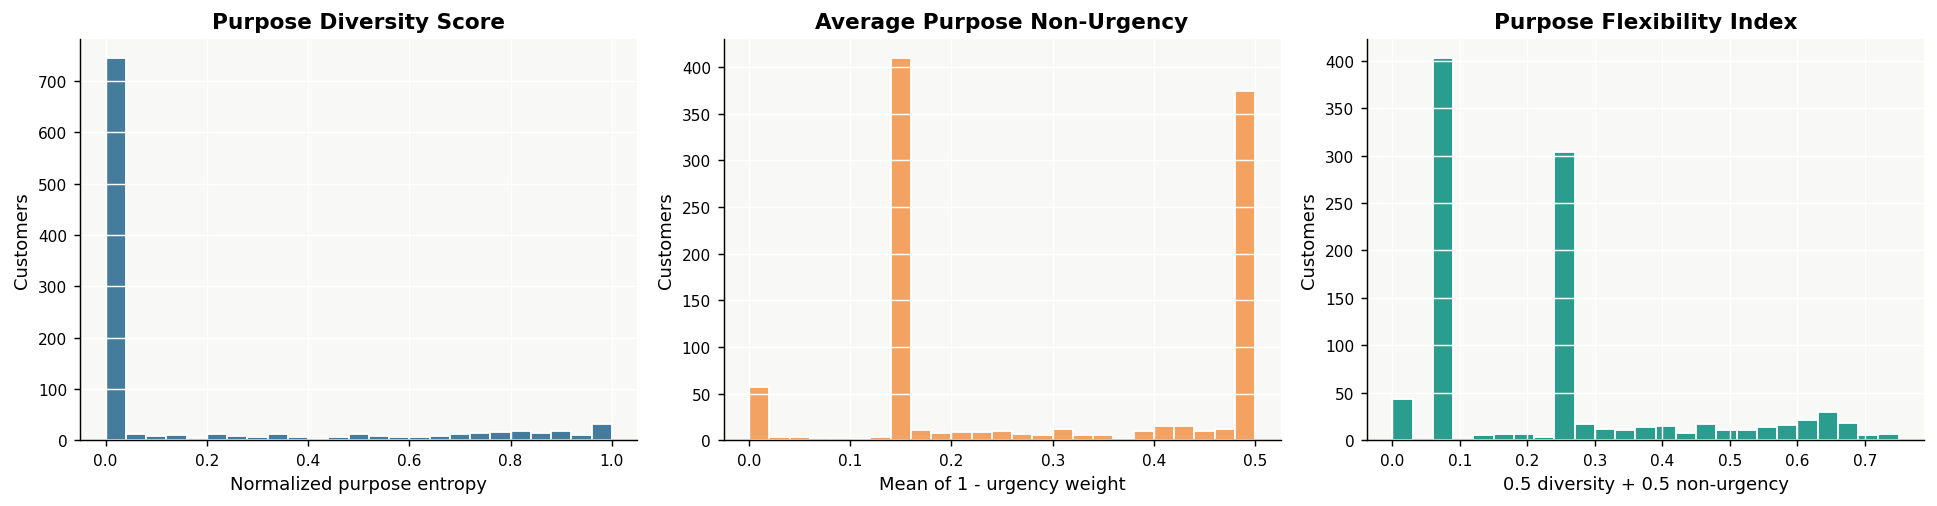

In [9]:
PURPOSE_URGENCY_WEIGHTS = {
    'Dialysis': 1.00,
    'Medical': 0.85,
    'Work': 0.75,
    'School': 0.70,
    'General': 0.40,
    'Other': 0.35,
}


def purpose_entropy_norm(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


purpose_trips = df_index_clean.copy()
purpose_trips['purpose_urgency_weight'] = (
    purpose_trips['Purpose'].map(PURPOSE_URGENCY_WEIGHTS).fillna(0.50)
)
purpose_trips['trip_purpose_non_urgency_score'] = 1 - purpose_trips['purpose_urgency_weight']

customer_purpose_flexibility = (
    purpose_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_purposes=('Purpose', 'nunique'),
        purpose_diversity_score=('Purpose', purpose_entropy_norm),
        purpose_urgency_score=('purpose_urgency_weight', 'mean'),
        purpose_non_urgency_score=('trip_purpose_non_urgency_score', 'mean'),
        dominant_purpose=('Purpose', lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan),
    )
    .reset_index()
)

customer_purpose_flexibility['purpose_flexibility_index'] = (
    0.5 * customer_purpose_flexibility['purpose_diversity_score']
    + 0.5 * customer_purpose_flexibility['purpose_non_urgency_score']
)
customer_purpose_flexibility = customer_purpose_flexibility.sort_values(
    ['purpose_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in purpose flexibility analysis: {len(customer_purpose_flexibility):,}")
print('Purpose urgency weights used:')
display(pd.DataFrame({
    'Purpose': list(PURPOSE_URGENCY_WEIGHTS.keys()),
    'urgency_weight': list(PURPOSE_URGENCY_WEIGHTS.values()),
    'non_urgency_score': [1 - v for v in PURPOSE_URGENCY_WEIGHTS.values()],
}).style.format({'urgency_weight': '{:.2f}', 'non_urgency_score': '{:.2f}'}))

print('Top riders by purpose flexibility index:')
display(customer_purpose_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_purposes': '{:,.0f}',
    'purpose_diversity_score': '{:.3f}',
    'purpose_urgency_score': '{:.3f}',
    'purpose_non_urgency_score': '{:.3f}',
    'purpose_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    customer_purpose_flexibility['purpose_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Purpose Diversity Score')
axes[0].set_xlabel('Normalized purpose entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_purpose_flexibility['purpose_non_urgency_score'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Average Purpose Non-Urgency')
axes[1].set_xlabel('Mean of 1 - urgency weight')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_purpose_flexibility['purpose_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Purpose Flexibility Index')
axes[2].set_xlabel('0.5 diversity + 0.5 non-urgency')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()


### Customer Groups by Flexibility Level

This cell splits customers into `low` and `high` levels for temporal, geographical, and purpose flexibility. For each index, the mean value is included in the `low` group:

```text
low:  index <= mean(index)
high: index > mean(index)
```

With three binary dimensions, this creates 8 possible groups. The summary counts customers in each group and reports the average completion and cancellation rates using the clean all-status trip table.


Index means used as low/high thresholds, with the mean included in low:


,mean_threshold
temporal_flexibility_index,0.495
geographical_flexibility_index,0.421
purpose_flexibility_index,0.226


Customers with all three flexibility indices: 1,002


,temporal_flexibility_level,geographical_flexibility_level,purpose_flexibility_level,num_customers,avg_completion_rate,avg_cancellation_rate,avg_temporal_flexibility_index,avg_geographical_flexibility_index,avg_purpose_flexibility_index,group_label
0,low,low,low,106,15.8%,77.5%,0.102,0.060,0.067,T: low | G: low | P: low
1,low,low,high,77,50.4%,46.0%,0.187,0.148,0.314,T: low | G: low | P: high
2,low,high,low,118,46.5%,46.9%,0.346,0.489,0.062,T: low | G: high | P: low
3,low,high,high,186,50.0%,43.1%,0.373,0.580,0.285,T: low | G: high | P: high
4,high,low,low,99,44.1%,51.7%,0.757,0.361,0.090,T: high | G: low | P: low
5,high,low,high,77,51.5%,45.4%,0.703,0.350,0.430,T: high | G: low | P: high
6,high,high,low,149,41.4%,52.2%,0.667,0.471,0.074,T: high | G: high | P: low
7,high,high,high,190,50.2%,46.2%,0.695,0.557,0.429,T: high | G: high | P: high


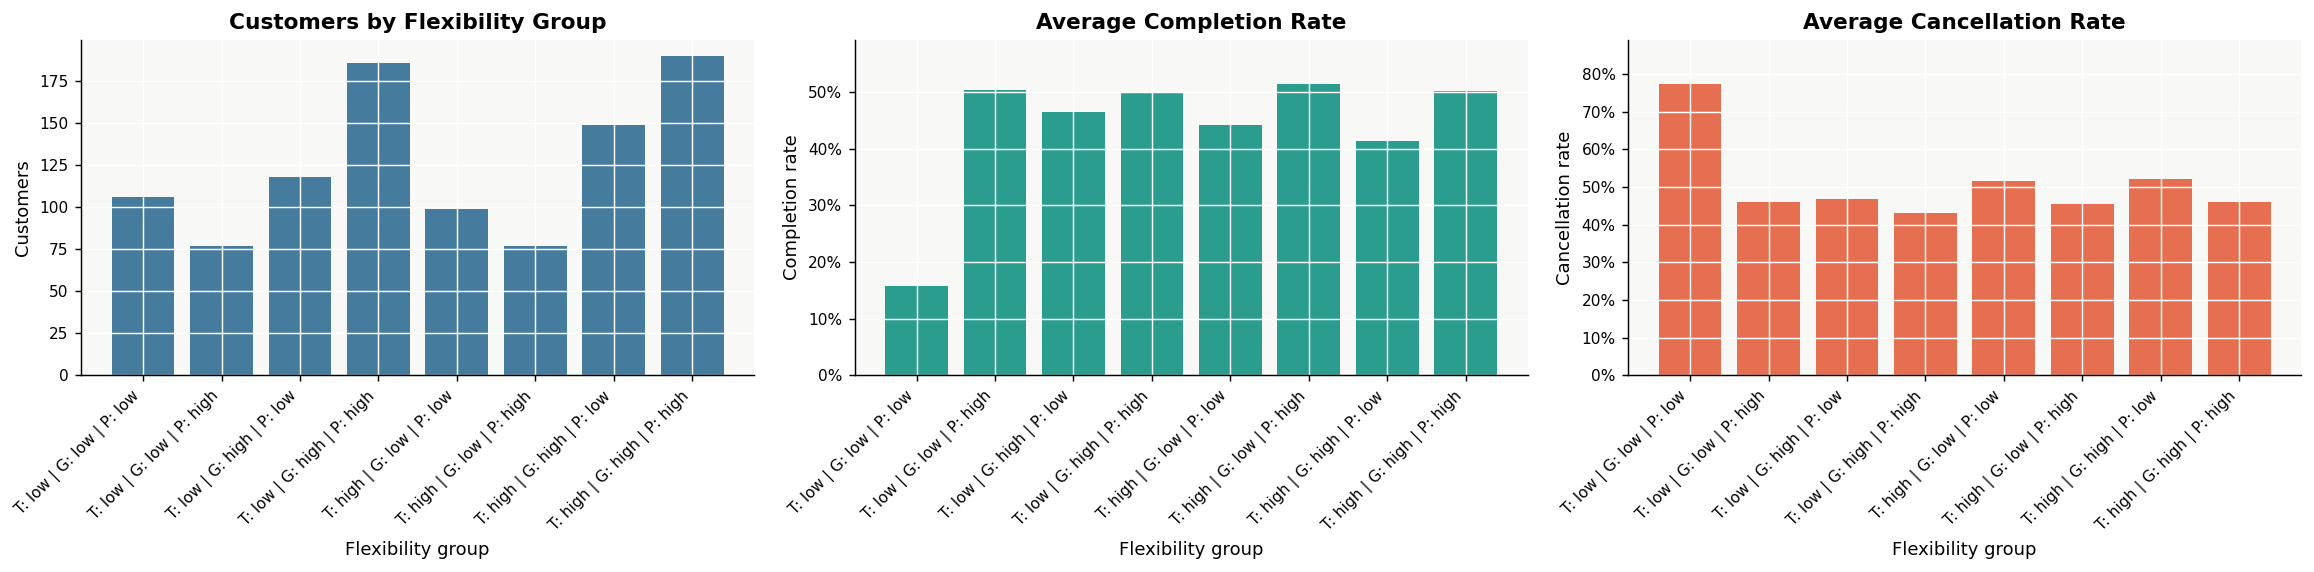

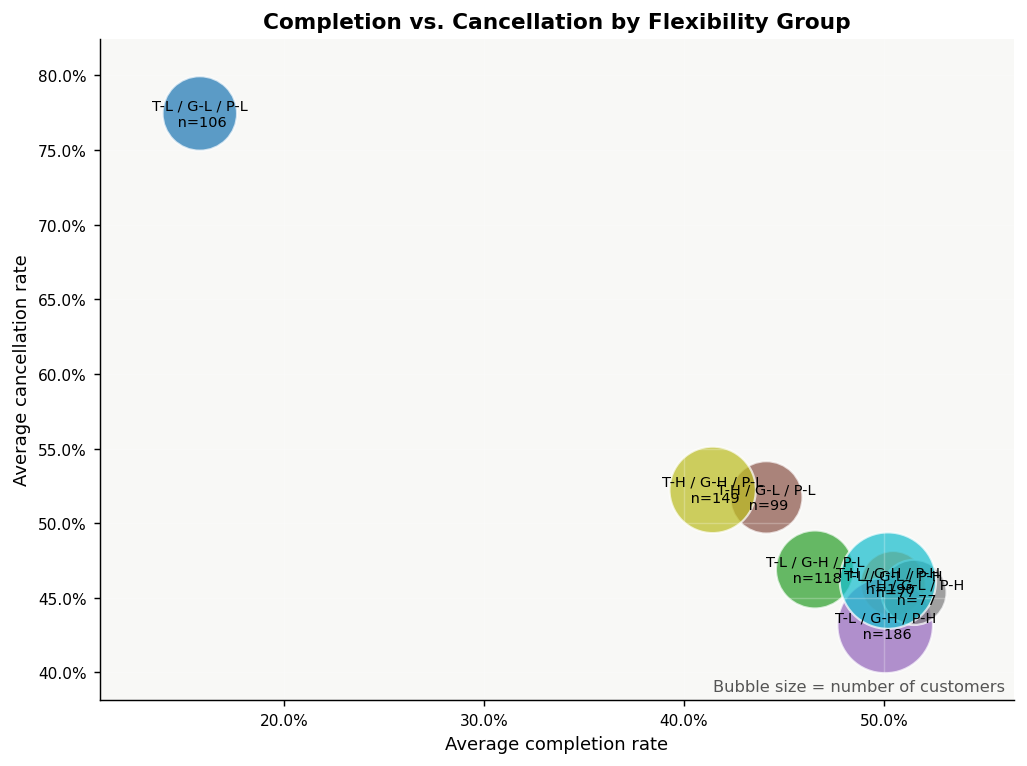

In [10]:
status_for_grouping = df_index_clean.copy()
status_for_grouping['status_clean'] = (
    status_for_grouping['Trip Status'].astype('string').str.strip().str.lower()
)
completed_statuses = {'comp', 'completed'}
cancelled_statuses = {'cancel', 'canceled', 'cancelled'}

customer_status_rates = (
    status_for_grouping
    .groupby('Customer Number')
    .agg(
        total_clean_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(completed_statuses).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(cancelled_statuses).sum()),
    )
    .reset_index()
)
customer_status_rates['completion_rate'] = (
    customer_status_rates['completed_trips'] / customer_status_rates['total_clean_trips']
)
customer_status_rates['cancellation_rate'] = (
    customer_status_rates['cancelled_trips'] / customer_status_rates['total_clean_trips']
)

customer_index_groups = (
    customer_temporal_flexibility[[
        'Customer Number', 'temporal_flexibility_index'
    ]]
    .merge(
        customer_geographical_flexibility[[
            'Customer Number', 'geographical_flexibility_index'
        ]],
        on='Customer Number',
        how='inner',
    )
    .merge(
        customer_purpose_flexibility[[
            'Customer Number', 'purpose_flexibility_index'
        ]],
        on='Customer Number',
        how='inner',
    )
    .merge(customer_status_rates, on='Customer Number', how='left')
)

index_columns = [
    'temporal_flexibility_index',
    'geographical_flexibility_index',
    'purpose_flexibility_index',
]
index_mean_thresholds = customer_index_groups[index_columns].mean(skipna=True)

for index_column in index_columns:
    level_column = index_column.replace('_flexibility_index', '_flexibility_level')
    customer_index_groups[level_column] = np.where(
        customer_index_groups[index_column] <= index_mean_thresholds[index_column],
        'low',
        'high',
    )

level_columns = [
    'temporal_flexibility_level',
    'geographical_flexibility_level',
    'purpose_flexibility_level',
]
all_level_groups = pd.MultiIndex.from_product(
    [['low', 'high']] * len(level_columns),
    names=level_columns,
)

flexibility_group_summary = (
    customer_index_groups
    .groupby(level_columns)
    .agg(
        num_customers=('Customer Number', 'nunique'),
        avg_completion_rate=('completion_rate', 'mean'),
        avg_cancellation_rate=('cancellation_rate', 'mean'),
        avg_temporal_flexibility_index=('temporal_flexibility_index', 'mean'),
        avg_geographical_flexibility_index=('geographical_flexibility_index', 'mean'),
        avg_purpose_flexibility_index=('purpose_flexibility_index', 'mean'),
    )
    .reindex(all_level_groups)
    .reset_index()
)
flexibility_group_summary['num_customers'] = (
    flexibility_group_summary['num_customers'].fillna(0).astype(int)
)
flexibility_group_summary['group_label'] = (
    'T: ' + flexibility_group_summary['temporal_flexibility_level']
    + ' | G: ' + flexibility_group_summary['geographical_flexibility_level']
    + ' | P: ' + flexibility_group_summary['purpose_flexibility_level']
)

print('Index means used as low/high thresholds, with the mean included in low:')
display(index_mean_thresholds.rename('mean_threshold').to_frame().style.format('{:.3f}'))

print(f"Customers with all three flexibility indices: {len(customer_index_groups):,}")
display(flexibility_group_summary.style.format({
    'num_customers': '{:,.0f}',
    'avg_completion_rate': '{:.1%}',
    'avg_cancellation_rate': '{:.1%}',
    'avg_temporal_flexibility_index': '{:.3f}',
    'avg_geographical_flexibility_index': '{:.3f}',
    'avg_purpose_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
plot_data = flexibility_group_summary.copy()
x = np.arange(len(plot_data))

axes[0].bar(x, plot_data['num_customers'], color='#457b9d')
axes[0].set_title('Customers by Flexibility Group')
axes[0].set_ylabel('Customers')

axes[1].bar(x, plot_data['avg_completion_rate'], color='#2a9d8f')
axes[1].set_title('Average Completion Rate')
axes[1].set_ylabel('Completion rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
completion_max = plot_data['avg_completion_rate'].dropna().max()
axes[1].set_ylim(0, min(1.0, completion_max * 1.15) if pd.notna(completion_max) else 1.0)

axes[2].bar(x, plot_data['avg_cancellation_rate'], color='#e76f51')
axes[2].set_title('Average Cancellation Rate')
axes[2].set_ylabel('Cancellation rate')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
cancellation_max = plot_data['avg_cancellation_rate'].dropna().max()
axes[2].set_ylim(0, min(1.0, cancellation_max * 1.15) if pd.notna(cancellation_max) else 1.0)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(plot_data['group_label'], rotation=45, ha='right')
    ax.set_xlabel('Flexibility group')

plt.tight_layout()
plt.show()

bubble_plot_data = flexibility_group_summary[
    flexibility_group_summary['num_customers'] > 0
].dropna(subset=['avg_completion_rate', 'avg_cancellation_rate']).copy()
bubble_plot_data['group_code'] = (
    'T-' + bubble_plot_data['temporal_flexibility_level'].str[0].str.upper()
    + ' / G-' + bubble_plot_data['geographical_flexibility_level'].str[0].str.upper()
    + ' / P-' + bubble_plot_data['purpose_flexibility_level'].str[0].str.upper()
)

if not bubble_plot_data.empty:
    max_customers = bubble_plot_data['num_customers'].max()
    bubble_sizes = 250 + 2600 * bubble_plot_data['num_customers'] / max_customers

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        bubble_plot_data['avg_completion_rate'],
        bubble_plot_data['avg_cancellation_rate'],
        s=bubble_sizes,
        c=np.arange(len(bubble_plot_data)),
        cmap='tab10',
        alpha=0.72,
        edgecolor='white',
        linewidth=1.2,
    )

    for _, row in bubble_plot_data.iterrows():
        ax.annotate(
            f"{row['group_code']}\n n={row['num_customers']:,}",
            (row['avg_completion_rate'], row['avg_cancellation_rate']),
            ha='center',
            va='center',
            fontsize=8,
        )

    x_min = max(0, bubble_plot_data['avg_completion_rate'].min() - 0.05)
    x_max = min(1, bubble_plot_data['avg_completion_rate'].max() + 0.05)
    y_min = max(0, bubble_plot_data['avg_cancellation_rate'].min() - 0.05)
    y_max = min(1, bubble_plot_data['avg_cancellation_rate'].max() + 0.05)
    if x_min == x_max:
        x_min, x_max = max(0, x_min - 0.05), min(1, x_max + 0.05)
    if y_min == y_max:
        y_min, y_max = max(0, y_min - 0.05), min(1, y_max + 0.05)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_xlabel('Average completion rate')
    ax.set_ylabel('Average cancellation rate')
    ax.set_title('Completion vs. Cancellation by Flexibility Group')
    ax.text(
        0.99,
        0.01,
        'Bubble size = number of customers',
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=9,
        color='#555555',
    )
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()



# 3. Add the zone categorin.

In [ ]:
CBG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/jefferson_county_cbg_data_2021.csv")
df_cbg = pd.read_csv(CBG_PATH)

print(f"CBG rows: {len(df_cbg):,}")
print(f"CBG columns: {list(df_cbg.columns)}")
df_cbg.head(3)


# 4. Add the Alabama block group shapefile, filters to Jefferson County CBG polygons 

In [ ]:
import geopandas as gpd

BG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp")

# Load Jefferson County block group polygons and attach the CBG attributes.
cbg_poly = gpd.read_file(BG_PATH)
cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

df_cbg = df_cbg.copy()
df_cbg['GEOID'] = (
    df_cbg['state'].astype(int).astype(str).str.zfill(2)
    + df_cbg['county'].astype(int).astype(str).str.zfill(3)
    + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
    + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
)
cbg_poly = cbg_poly.merge(df_cbg, on='GEOID', how='left')

# Spatially mark each trip's pickup and dropoff block group.
pickup_points = gpd.GeoDataFrame(
    df_clean[['pickup_lon', 'pickup_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
pickup_points['trip_index'] = df_clean.index

dropoff_points = gpd.GeoDataFrame(
    df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
dropoff_points['trip_index'] = df_clean.index

pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')

pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

pickup_blocks = set(df_clean['pickup_bg_geoid'].dropna())
dropoff_blocks = set(df_clean['dropoff_bg_geoid'].dropna())

pickup_counts = df_clean['pickup_bg_geoid'].value_counts()
dropoff_counts = df_clean['dropoff_bg_geoid'].value_counts()
cbg_poly['pickup_trip_count'] = cbg_poly['GEOID'].map(pickup_counts).fillna(0).astype(int)
cbg_poly['dropoff_trip_count'] = cbg_poly['GEOID'].map(dropoff_counts).fillna(0).astype(int)

print(f"Pickup points mapped to CBGs: {df_clean['pickup_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Dropoff points mapped to CBGs: {df_clean['dropoff_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Pickup blocks: {len(pickup_blocks):,}; dropoff blocks: {len(dropoff_blocks):,}; overlap: {len(pickup_blocks & dropoff_blocks):,}")

from matplotlib.colors import PowerNorm

vmax = max(cbg_poly['pickup_trip_count'].max(), cbg_poly['dropoff_trip_count'].max())
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
pickup_plot = pickup_points.sample(min(1500, len(pickup_points)), random_state=42)
dropoff_plot = dropoff_points.sample(min(1500, len(dropoff_points)), random_state=42)

minx, miny, maxx, maxy = pickup_points.total_bounds
dx = (maxx - minx) * 0.08
dy = (maxy - miny) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

cbg_poly.plot(
    ax=axes[0], column='pickup_trip_count', cmap='Blues', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed pickup trips per CBG', 'shrink': 0.72},
)
pickup_plot.plot(ax=axes[0], markersize=2.0, color='black', alpha=0.22)
axes[0].set_title('Pickup Demand by Census Block Group')

cbg_poly.plot(
    ax=axes[1], column='dropoff_trip_count', cmap='Oranges', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed dropoff trips per CBG', 'shrink': 0.72},
)
dropoff_plot.plot(ax=axes[1], markersize=2.0, color='black', alpha=0.22)
axes[1].set_title('Dropoff Demand by Census Block Group')

for ax in axes:
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_axis_off()

fig.suptitle('Completed Trip Pickup and Dropoff Demand in Jefferson County CBGs', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()


RFI = w1 * temporal_flexibility
    + w2 * purpose_flexibility
    + w3 * geographical_flexibility
    - w4 * regularity_penalty

